In [70]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn

plt.rcParams['figure.figsize'] = [12, 12]

In [1]:
import copy

import numpy

import cloudvolume
import kimimaro
import fastremap

np = numpy

/allen/programs/celltypes/workgroups/em-connectomics/russelt/axconn_pcg_test/.pixi/envs/py311-conda-lab/lib/python3.11/site-packages/python_jsonschema_objects/classbuilder.py:643: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if clsdata.get(


In [2]:
import ac_pcg.label
import ac_pcg.chunks
import ac_pcg.skeletons

from ac_pcg.pcgraph.edges import Edges
from ac_pcg.pcgraph.edges import EDGE_TYPES
from ac_pcg.io.edges import put_chunk_edges

In [3]:
import gzip
import pathlib
import pickle

def read_gzip_array(fn, preprocess_func=lambda x: x):
    with gzip.open(fn, "rb") as f:
        a = numpy.load(f)
    return preprocess_func(a)

test_data_path = pathlib.Path(
    "/allen/programs/celltypes/workgroups/em-connectomics/russelt/pcg_axconn/test_data_strip/"
)

test_data_labeled_array_path = test_data_path / "H17_x55_S32_230412_Pos42.npy.gz"
test_skels_path = test_data_path / "H17_x55_S32_230412_Pos42.skels.pkl"

In [4]:
labeled_array = read_gzip_array(test_data_labeled_array_path)
with test_skels_path.open(mode="rb") as skels_fobj:
    label_skels = pickle.load(skels_fobj)

In [5]:
%%time
import rtree

skel_id_to_bboxes = {sk_id: cloudvolume.Bbox.from_points(sk.vertices) for sk_id, sk in label_skels.items()}


p = rtree.index.Property()
p.dimension = 3
label_skel_idx = rtree.index.Index(
    ((sk_id, skel_bb.to_list(), label_skels[sk_id]) for sk_id, skel_bb in skel_id_to_bboxes.items()),
    properties=p
)

CPU times: user 3.49 s, sys: 236 ms, total: 3.73 s
Wall time: 3.82 s


In [6]:
labeled_array_bbox = cloudvolume.CloudVolume
labeled_array_chunksize = numpy.array((128, 128, 128))

In [7]:
%time skel_id_to_bboxes = {sk_id: cloudvolume.Bbox.from_points(sk.vertices) for sk_id, sk in label_skels.items()}

CPU times: user 1.34 s, sys: 68 ms, total: 1.41 s
Wall time: 1.4 s


In [8]:
def get_bbox_chunks(bbox, chunk_size, offset=None):
    if offset is not None:
        raise NotImplementedError
    (chunk_min, chunk_max), (remainder_min, remainder_max) = numpy.divmod(
        numpy.array([bbox.minpt, bbox.maxpt]), chunk_size)
    # chunk_max += remainder_max.astype(bool)

    # TODO could be more clever about dims
    imin, jmin, kmin = chunk_min
    imax, jmax, kmax = chunk_max
    chunks = np.mgrid[imin:imax+1:1, jmin:jmax+1:1, kmin:kmax+1:1].reshape(3, -1).T

    return chunks

In [9]:
%time skel_to_chunks = {sk_id: get_bbox_chunks(sk_bbox, labeled_array_chunksize) for sk_id, sk_bbox in skel_id_to_bboxes.items()}

CPU times: user 2.04 s, sys: 48 ms, total: 2.08 s
Wall time: 2.09 s


In [10]:
%time
chunk_to_skel_ids = {}
for sk_id, sk_chunks in skel_to_chunks.items():
    for sk_chunk in sk_chunks:
        try:
            chunk_to_skel_ids[tuple(sk_chunk)].append(sk_id)
        except KeyError:
            chunk_to_skel_ids[tuple(sk_chunk)] = [sk_id]

CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 13.1 μs


In [11]:
# TODO multiprocess futures w/ skeleton processing

In [12]:
def chunk_idx_to_bbox(chunk_idx, chunk_size, chunked_box_shape):
    chunk_mins = tuple(idx * chunk_d for idx, chunk_d in zip(chunk_idx, chunk_size))
    chunk_max = tuple(min(box_d, chunk_min + chunk_d) for chunk_min, chunk_d, box_d in zip(chunk_mins, chunk_size, chunked_box_shape))
    bbox = cloudvolume.Bbox(chunk_mins, chunk_max)
    return ac_pcg.chunks.ChunkBbox(
        bbox=bbox,
        chunk_idx=chunk_idx
    )

In [13]:
import dataclasses
import multiprocessing.shared_memory

@dataclasses.dataclass
class SharedArrayProperties:
    sharedmem_name: str
    shape: tuple
    dtype: numpy.dtype
    

def process_oversegment_array(arr, skels, label_func, oversegment_kwargs=None, relabel_zero=False):
    oversegment_kwargs = oversegment_kwargs or {}

    oversegmented_arr, oversegmented_skels = kimimaro.utility.oversegment(
        arr, skels, **oversegment_kwargs)

    # convert labels to uint64 layer/chunk indices
    lbl_map = {
        input_lbl: label_func(input_lbl)  # input_lbl: labeler.encode_chunk_seg(chunk_box.chunk_idx, input_lbl)
        for input_lbl in fastremap.unique(
            oversegmented_arr
        )
    }
    if not relabel_zero:
        lbl_map[0] = 0

    relabeled_arr = fastremap.remap(oversegmented_arr, lbl_map)

    for skel in oversegmented_skels:
        skel.segments = fastremap.remap(skel.segments, lbl_map)

    return relabeled_arr, oversegmented_skels


def process_oversegment_bbox_shmem(bbox, sharedarray_props, *args, **kwargs):
    existing_shm = multiprocessing.shared_memory.SharedMemory(name=sharedarray_props.sharedmem_name)
    arr = numpy.ndarray(sharedarray_props.shape, dtype=sharedarray_props.dtype, buffer=existing_shm.buf)
    bbox_arr = arr[bbox.to_slices()]
    
    result = process_oversegment_array(arr, *args, **kwargs)
    existing_shm.close()
    return result

In [42]:
import concurrent.futures
import functools
import time

output_skels = copy.deepcopy(label_skels)
labeler = ac_pcg.label.ChunkLabeler()
output_arr = numpy.empty(labeled_array.shape, dtype=numpy.uint64)

shm = multiprocessing.shared_memory.SharedMemory(create=True, size=labeled_array.nbytes)
shared_array = np.ndarray(labeled_array.shape, dtype=labeled_array.dtype, buffer=shm.buf)
numpy.copyto(shared_array, labeled_array)
shared_array_props = SharedArrayProperties(shm.name, shared_array.shape, shared_array.dtype)

tic = time.time()
concurrency = 10



with concurrent.futures.ProcessPoolExecutor(max_workers=concurrency) as e:
    fut_to_chunk_idx = {}
    for chunk_num, (chunk_idx, chunk_skel_ids) in enumerate(chunk_to_skel_ids.items()):
        chunk_box = chunk_idx_to_bbox(chunk_idx, labeled_array_chunksize, labeled_array.shape)
        chunk_contains_bb = cloudvolume.Bbox(
            chunk_box.bbox.minpt,
            chunk_box.bbox.maxpt - 1
        )
        skels_indices_tuples = filter(None, (
            ac_pcg.skeletons.bboxed_skel(label_skels[chunk_skel_id], chunk_contains_bb)
            for chunk_skel_id in chunk_skel_ids))

        try:
            skels, skel_indices = zip(*skels_indices_tuples)
        except ValueError:
            continue

        # subvol_arr = labeled_array[chunk_box.bbox.to_slices()]
        label_func = functools.partial(labeler.encode_chunk_seg, chunk_idx)

        fut = e.submit(
                process_oversegment_bbox_shmem,
                chunk_box.bbox, shared_array_props,
                skels, label_func=label_func, oversegment_kwargs={
                    "downsample": 6,
                    "progress": False
                })
        fut_to_chunk_idx[fut] = chunk_idx

        # relabeled_arr, relabeled_skels = process_oversegment_array(
        #     subvol_arr, skels,
        #     label_func=lambda x: labeler.encode_chunk_seg(chunk_idx, x),
        #     oversegment_kwargs={
        #         "downsample": 6,
        #         "progress": False
        #     })

    for fut in concurrent.futures.as_completed(fut_to_chunk_idx.keys()):
        chunk_idx = fut_to_chunk_idx[fut]
        chunk_box = chunk_idx_to_bbox(chunk_idx, labeled_array_chunksize, labeled_array.shape)

        relabeled_arr, relabeled_skels = fut.result()

        output_arr[chunk_box.bbox.to_slices()] = relabeled_arr[...]
    
        for i, (skel, subvol_indices) in enumerate(zip(relabeled_skels, skel_indices)):
            output_skel = output_skels[skel.id]
            try:
                output_skel.segments[subvol_indices] = skel.segments
            except AttributeError:
                output_skel.add_vertex_attribute(
                    "segments",
                    numpy.zeros(output_skel.vertices.shape[0], dtype=numpy.uint64)
                )
                output_skel.segments[subvol_indices] = skel.segments
        if not chunk_num % 10:
            print(chunk_num, time.time() - tic, flush=True)

print(time.time() - tic)

IndexError: Selected voxel [18446744073709545089                    2                   16] was not located inside the array.

In [58]:
import time

output_skels = copy.deepcopy(label_skels)
labeler = ac_pcg.label.ChunkLabeler()
output_arr = numpy.empty(labeled_array.shape, dtype=numpy.uint64)

tic = time.time()

for chunk_num, (chunk_idx, chunk_skel_ids) in enumerate(chunk_to_skel_ids.items()):
    chunk_box = chunk_idx_to_bbox(chunk_idx, labeled_array_chunksize, labeled_array.shape)
    chunk_contains_bb = cloudvolume.Bbox(
        chunk_box.bbox.minpt,
        chunk_box.bbox.maxpt - 1
    )
    skels_indices_tuples = filter(None, (
        ac_pcg.skeletons.bboxed_skel(label_skels[chunk_skel_id], chunk_contains_bb)
        for chunk_skel_id in chunk_skel_ids))

    try:
        skels, skel_indices = zip(*skels_indices_tuples)
    except ValueError:
        continue

    subvol_arr = labeled_array[chunk_box.bbox.to_slices()]

    relabeled_arr, relabeled_skels = process_oversegment_array(
        subvol_arr, skels,
        label_func=lambda x: labeler.encode_chunk_seg(chunk_idx, x),
        oversegment_kwargs={
            "downsample": 6,
            "progress": False
        })

    output_arr[chunk_box.bbox.to_slices()] = relabeled_arr[...]
    
    for i, (skel, subvol_indices) in enumerate(zip(relabeled_skels, skel_indices)):
        output_skel = output_skels[skel.id]
        try:
            output_skel.segments[subvol_indices] = skel.segments
        except AttributeError:
            output_skel.add_vertex_attribute(
                "segments",
                numpy.zeros(output_skel.vertices.shape[0], dtype=numpy.uint64)
            )
            output_skel.segments[subvol_indices] = skel.segments
    if not chunk_num % 10:
        print(chunk_num, time.time() - tic, flush=True)

print(time.time() - tic)

0 0.608957052230835
10 5.596571683883667
20 9.909541130065918
30 13.785521507263184
40 16.98548698425293
50 20.168755769729614
60 23.729313373565674
70 27.753839254379272
80 30.728767156600952
90 34.260780811309814
100 39.56364917755127
110 44.5767343044281
120 47.54689383506775
130 50.978556632995605
140 54.878836154937744
150 57.915262937545776
160 61.086875677108765
170 64.08435821533203
180 66.8785707950592
190 71.056077003479
200 74.62950849533081
210 76.82539629936218
220 79.48273372650146
230 81.21882009506226
240 82.47214388847351
250 83.48361015319824
260 85.43737697601318
270 89.46333861351013
280 92.04424262046814
290 94.94220757484436
300 97.72058844566345
310 98.93434762954712
320 103.10883331298828
330 107.1193151473999
340 110.70183873176575
350 112.9698133468628
360 116.07957887649536
370 118.7097339630127
380 119.82684111595154
390 121.97187757492065
410 123.84023022651672
420 125.45921874046326
430 127.5181074142456
440 130.04341173171997
450 132.80863523483276
460 13

In [15]:
# TODO concurrent processing, serial vertex assignment.
#   serial chunk processing method below

In [14]:
# alternatively, run over all chunks
# FIXME this fucks up the zeros

import time

chunk_size = (128, 128, 128)
chunk_boxes = ac_pcg.chunks.iterate_chunk_slice_boxes(
    labeled_array.shape, chunk_size)

labeler = ac_pcg.label.ChunkLabeler()

output_arr = numpy.empty(labeled_array.shape, dtype=numpy.uint64)

output_skels = copy.deepcopy(label_skels)

tic = time.time()
for chunk_num, chunk_box in enumerate(chunk_boxes):
    chunk_contains_bb = cloudvolume.Bbox(
        chunk_box.bbox.minpt,
        chunk_box.bbox.maxpt - 1
    )
    subvol_arr = labeled_array[chunk_box.bbox.to_slices()]
    skels_indices_tuples = filter(None, (
        ac_pcg.skeletons.bboxed_skel(res.object, chunk_contains_bb)
        for res in label_skel_idx.intersection(
            chunk_contains_bb.to_list(), objects=True
        )
    ))
    try:
        subvol_skels, subvol_skel_indices = zip(*skels_indices_tuples)
    except ValueError:
        continue

    oversegmented_subvol_arr, oversegmented_subvol_skels = kimimaro.utility.oversegment(
        subvol_arr, subvol_skels, downsample=6, progress=False)

    # convert labels to uint64 layer/chunk indices
    lbl_map = {
        input_lbl: labeler.encode_chunk_seg(chunk_box.chunk_idx, input_lbl)
        for input_lbl in fastremap.unique(
            oversegmented_subvol_arr
        )
    }
    relabeled_arr = fastremap.remap(oversegmented_subvol_arr, lbl_map)
    
    output_arr[chunk_box.bbox.to_slices()] = relabeled_arr[...]

    # map new indices to original skel vertices
    for i, (skel, subvol_indices) in enumerate(zip(oversegmented_subvol_skels, subvol_skel_indices)):
        output_skel = output_skels[skel.id]
        skel.segments = fastremap.remap(skel.segments, lbl_map)
        try:
            output_skel.segments[subvol_indices] = skel.segments
        except AttributeError:
            output_skel.add_vertex_attribute(
                "segments",
                numpy.zeros(output_skel.vertices.shape[0], dtype=numpy.uint64)
            )
            output_skel.segments[subvol_indices] = skel.segments
    

    if not chunk_num % 10:
        print(chunk_num, time.time() - tic, flush=True)

print(time.time() - tic)

90 0.4999210834503174
100 1.3487062454223633
120 3.8052761554718018
130 5.498478651046753
140 6.878988027572632
150 8.488983392715454
160 9.831039190292358
170 11.366411447525024
180 13.130510568618774
190 15.055659770965576
200 16.894375324249268
210 18.535940647125244
220 20.480347871780396
230 22.278133630752563
240 23.997191190719604
250 25.811439275741577
260 27.57244873046875
270 29.681634426116943
280 32.068779945373535
290 34.43297719955444
300 36.78767442703247
310 39.245039224624634
320 41.20454120635986
330 42.95126938819885
340 44.43541598320007
350 45.97043776512146
360 47.96721529960632
370 50.04242014884949
390 53.422455072402954
400 55.44630193710327
420 58.68640851974487
430 60.25001335144043
450 63.61974120140076
460 65.43252420425415
480 68.50502967834473
490 69.99774956703186
500 71.39244723320007
510 72.7943959236145
520 74.25219440460205
530 75.55480194091797
540 77.15961575508118
550 78.68018198013306
560 79.9271559715271
570 81.20371842384338
580 82.508682012557

In [15]:
# write out protobuf edges and precomputed array

In [16]:
def label_chunk(labeler, chunk):
    layer_offset = numpy.uint64(64 - labeler.n_bits_for_layer_id)
    x_offset = numpy.uint64(layer_offset - labeler.spatial_bit_count)
    y_offset = numpy.uint64(x_offset - labeler.spatial_bit_count)
    z_offset = numpy.uint64(y_offset - labeler.spatial_bit_count)

    layer = numpy.uint64(labeler.level)
    x, y, z = numpy.uint64(chunk)

    segid_bits = numpy.uint64(64 - labeler.n_bits_for_layer_id - 3 * labeler.spatial_bit_count)

    return numpy.uint64(
      layer << layer_offset | x << x_offset | y << y_offset | z << z_offset
    ) >> segid_bits


def chunk_edges_from_skeleton(skel, query_chunk, labeler):
    seg_edges = skel.segments[skel.edges]
    reduced_seg_edges = numpy.unique(
        numpy.sort(
            seg_edges[
            (seg_edges[:, 0] != seg_edges[:, 1])
            ], axis=1
        ),
        axis=0)

    segid_bits = numpy.uint64(64 - labeler.n_bits_for_layer_id - 3 * labeler.spatial_bit_count)                                                                                                                                                                                                       

    # calculate layer and chunk label for edges
    layer_chunk_edges = reduced_seg_edges >> segid_bits

    # calculate chunk label and find occurences
    query_layer_chunk_idx = label_chunk(labeler, query_chunk)
    query_chunk_edges_mask = (layer_chunk_edges == query_layer_chunk_idx)

    in_chunk_edges_mask = query_chunk_edges_mask[:, 0] & query_chunk_edges_mask[:, 1]
    between_chunk_edges_mask = query_chunk_edges_mask[:, 0] ^ query_chunk_edges_mask[:, 1]    

    in_chunk_edges = reduced_seg_edges[in_chunk_edges_mask]
    between_chunk_edges = reduced_seg_edges[between_chunk_edges_mask]
    return in_chunk_edges, between_chunk_edges

In [17]:
edge_output_loc = "file:///allen/programs/celltypes/workgroups/em-connectomics/russelt/ac_pcg_example/H17_x55_S32_230412_Pos42/redo_zeros/edges"
for chunk, chunk_skel_ids in chunk_to_skel_ids.items():
    in_chunk_edge_results = []
    between_chunk_edge_results = []
    for skel_id in chunk_skel_ids:
        # TODO probably just use edges of all skels r.t. iterate over skel vertices
        skel = output_skels[skel_id]
        skel_in_chunk_edge_arr, skel_between_chunk_edge_arr = chunk_edges_from_skeleton(skel, chunk, labeler)
        in_chunk_edge_results.append(skel_in_chunk_edge_arr)
        between_chunk_edge_results.append(skel_between_chunk_edge_arr)

    in_chunk_edge_arr = numpy.concatenate(in_chunk_edge_results)
    between_chunk_edge_arr = numpy.concatenate(between_chunk_edge_results)
    in_chunk_edges = Edges(*in_chunk_edge_arr.T)
    between_chunk_edges = Edges(*between_chunk_edge_arr.T)
    # cross_chunk_edges are not generated in this segmentation method
    cross_chunk_edges = Edges([], [])

    edges_d = {
        EDGE_TYPES.in_chunk: in_chunk_edges,
        EDGE_TYPES.between_chunk: between_chunk_edges,
        EDGE_TYPES.cross_chunk: cross_chunk_edges
    }
    
    put_chunk_edges(edge_output_loc, chunk, edges_d, compression_level=22)

In [18]:
%%time
# get component arrays from skeletons

def components_from_skel(skel):
    vtxs = numpy.unique(skel.segments)
    components = [vtxs.size] + vtxs.tolist()
    return components
    

components = []
for skel_id in skel_to_chunks:
    skel = output_skels[skel_id]
    skel_components = components_from_skel(skel)
    components.extend(skel_components)

components = numpy.array(components, dtype=numpy.uint64)

CPU times: user 624 ms, sys: 16 ms, total: 640 ms
Wall time: 639 ms


In [19]:
# chunk adjacency as a graph
# iterate over chunk edges, within n hops

# 

In [49]:
# get graph edge initialization from chunks
import itertools

def get_edges_dense(skels):
    """
    edges between all possible nodes based on a set of skeletons
    """
    vtxs = numpy.unique(skel.segments)
    edges_it = itertools.combinations(vtxs, 2)
    return numpy.array(edges_it)
    # TODO in-chunk vs between-chunk arrays from chunk_edges_in_skeleton
    
    


def get_edges_distance(skels_d, distance=None):
    """
    edges across skeletons based on euclidean distance from node id
    """
    # NOTE: for simplicity, uses an arbitrary point on the final skeletons
    if distance is None:
        raise NotImplementedError

    all_ids = []
    all_locs = []
    for skel_id, skel in skels_d.items():
        vtxs, indices = numpy.unique(skel.segments, return_index=True)
        vtx_locs = skel.vertices[indices]
        all_ids.extend(vtxs.tolist())
        all_locs.extend(vtx_locs.tolist())
    
    # build kdtree
    kdtree = scipy.spatial.KDTree(all_locs)
    pair_vtx_idxs_np = kdtree.query_pairs(r=distance, output_type='ndarray')

    pair_vtx_idxs_np[(pair_vtx_idxs_np[:, 0] != pair_vtx_idxs_np[:, 1])]
    
    edge_ids = numpy.array(all_ids)[pair_vtx_idxs_np]

    segid_bits = numpy.uint64(64 - labeler.n_bits_for_layer_id - 3 * labeler.spatial_bit_count)                                                                                                                                                                                                       

    # calculate layer and chunk label for edges
    layer_chunk_edges = edge_ids >> segid_bits

    # calculate chunk label and find occurences
    query_layer_chunk_idx = label_chunk(labeler, query_chunk)
    query_chunk_edges_mask = (layer_chunk_edges == query_layer_chunk_idx)

    in_chunk_edges_mask = query_chunk_edges_mask[:, 0] & query_chunk_edges_mask[:, 1]
    between_chunk_edges_mask = query_chunk_edges_mask[:, 0] ^ query_chunk_edges_mask[:, 1]    

    in_chunk_edges = edge_ids[in_chunk_edges_mask]
    between_chunk_edges = edge_ids[between_chunk_edges_mask]

    return in_chunk_edges, between_chunk_edges
        



In [50]:
%%time
in_chunk_edges, between_chunk_edges = get_edges_distance(output_skels, 100)

NameError: name 'query_chunk' is not defined

In [21]:
%%time
import scipy.spatial

distance=100

all_ids = []
all_locs = []
for skel_id, skel in output_skels.items():
    vtxs, indices = numpy.unique(skel.segments, return_index=True)
    vtx_locs = skel.vertices[indices]
    all_ids.extend(vtxs.tolist())
    all_locs.extend(vtx_locs.tolist())
    
kdtree = scipy.spatial.KDTree(all_locs)
pair_vtx_idxs = kdtree.query_pairs(r=distance)


CPU times: user 1min 12s, sys: 21.6 s, total: 1min 34s
Wall time: 1min 34s


In [24]:
all_ids[:10]

[101330991615836530,
 101330991615836553,
 101612466592546825,
 101612466592546854,
 101612466592546886,
 101612466592546909,
 101612466592546928,
 101612466592546963,
 101612466592546986,
 101612466592547022]

In [31]:
pair_vtx_idxs_np = kdtree.query_pairs(r=distance, output_type='ndarray')

In [46]:
pair_vtx_idxs_np[(pair_vtx_idxs_np[:, 0] != pair_vtx_idxs_np[:, 1])]

array([[ 41678,  51681],
       [ 41679,  51681],
       [ 51681,  62462],
       ...,
       [381496, 390041],
       [381497, 390041],
       [381496, 381497]])

0

In [32]:
pair_vtx_idxs_np

array([[ 41678,  51681],
       [ 41679,  51681],
       [ 51681,  62462],
       ...,
       [381496, 390041],
       [381497, 390041],
       [381496, 381497]])

In [35]:
edge_ids = numpy.array(all_ids)[pair_vtx_idxs_np]

In [22]:
pair_vtx_idxs

{(338998, 339388),
 (148843, 349257),
 (40058, 314303),
 (170088, 209400),
 (247841, 351727),
 (165149, 334534),
 (13274, 56290),
 (110982, 176573),
 (115363, 246116),
 (204332, 214657),
 (42018, 50292),
 (61349, 193258),
 (18230, 131433),
 (5313, 30452),
 (189873, 281795),
 (312286, 328156),
 (208841, 226476),
 (240929, 392442),
 (282624, 337263),
 (83333, 147267),
 (345375, 366380),
 (123572, 300729),
 (161834, 177244),
 (245682, 347281),
 (249903, 338843),
 (202492, 224486),
 (280785, 336764),
 (307733, 328466),
 (194412, 297960),
 (294176, 378029),
 (337496, 384675),
 (229030, 363996),
 (71115, 104546),
 (7154, 61892),
 (302913, 354288),
 (286215, 352191),
 (15827, 183967),
 (152431, 199030),
 (144654, 272313),
 (14232, 126488),
 (270126, 326201),
 (116284, 339090),
 (264086, 344995),
 (251395, 351662),
 (321916, 334618),
 (31012, 52049),
 (151969, 307051),
 (268905, 329501),
 (189128, 256320),
 (336830, 382720),
 (244973, 347127),
 (263349, 282070),
 (12866, 76601),
 (549, 144047)

In [113]:
from matplotlib.colors import ListedColormap

def plot_random_colormap_labels_safe(label_array, background_label=0):
    """
    Plots a label image with a random color map using matplotlib.imshow.
    Handles uint64 label arrays by remapping labels to a dense integer range.
    
    Parameters:
        label_array : 2D numpy array of integer labels (any integer dtype)
        background_label : label value to be shown as black
    """
    unique_labels = np.unique(label_array)
    
    # Map original labels to dense indices
    label_to_index = {val: i for i, val in enumerate(unique_labels)}
    dense_array = np.vectorize(label_to_index.get)(label_array)

    # Generate random colors
    rng = np.random.default_rng()
    colors = rng.uniform(0, 1, size=(len(unique_labels), 3))
    
    # Set background label (if it exists) to black
    if background_label in label_to_index:
        bg_idx = label_to_index[background_label]
        colors[bg_idx] = [0, 0, 0]

    cmap = ListedColormap(colors)
    
    plt.imshow(dense_array, cmap=cmap, interpolation='nearest')
    plt.axis('off')
    plt.show()

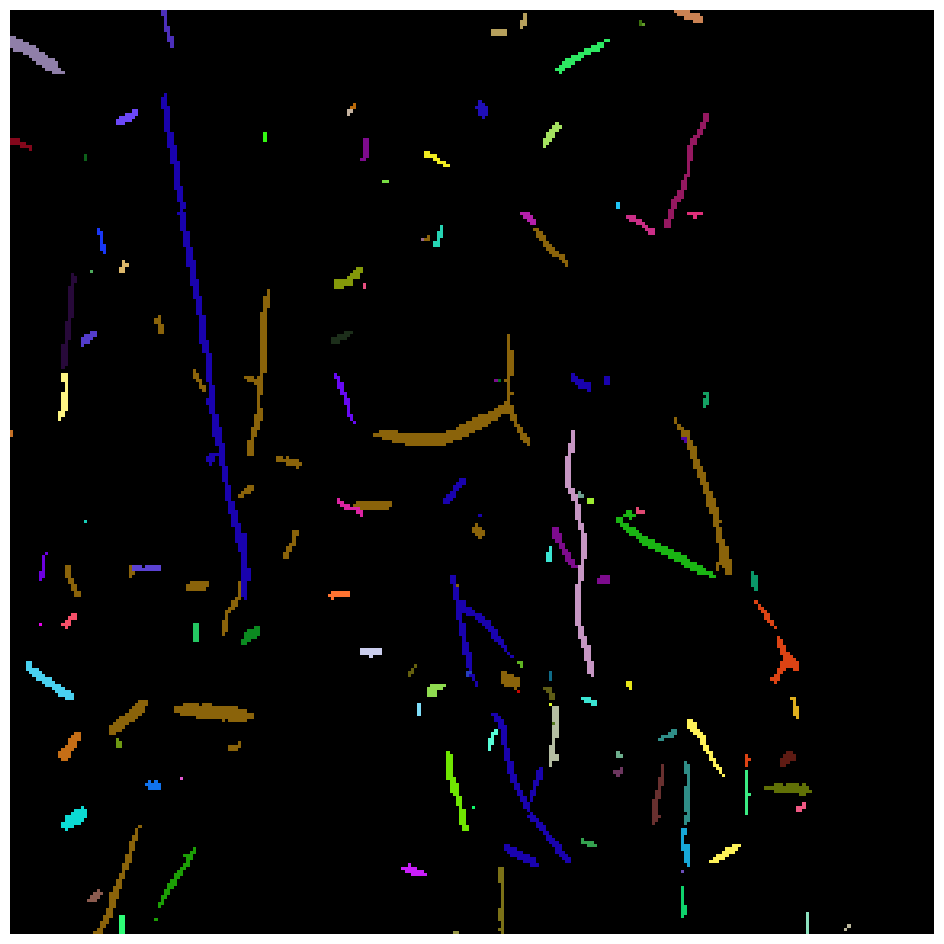

In [116]:
plot_random_colormap_labels_safe(labeled_array[6660:6670, :, :].max(axis=0))

In [20]:
# write out labeled supervoxel volume

In [21]:
list(labeled_array.shape)

[21568, 288, 288]

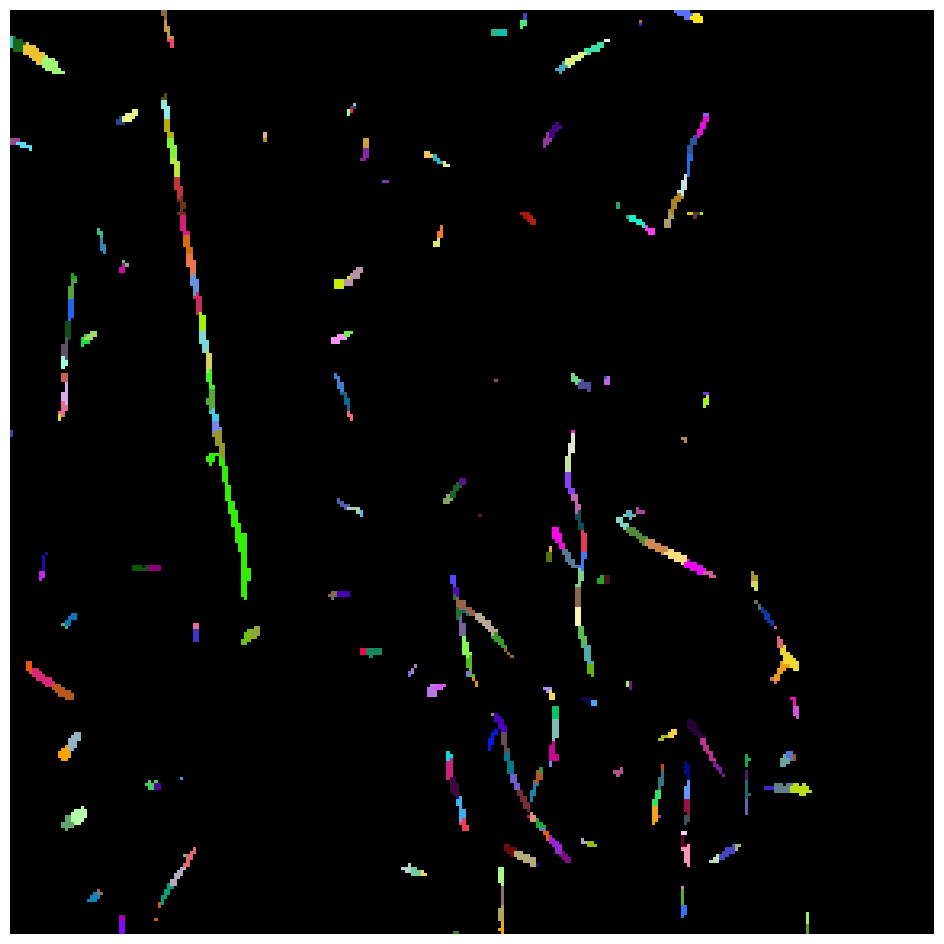

In [118]:
plot_random_colormap_labels_safe(output_arr[6660:6670, ...].max(axis=0))

In [109]:
numpy.unique(output_arr[6666, ...])

array([                0, 86694292826882049, 86694292826882050,
       86694292826882053, 86694292826882060, 86694292826882115,
       86694292826882116, 86694292826882139, 86694292826882184,
       86694292826882195, 86694292826882196, 86694292826882291,
       86694292826882296, 86694292826882304, 86694292826882308,
       86694292826882313, 86694292826882323, 86694292826882335,
       86694292826882336, 86694292826882356, 86694292826882357,
       86694292826882358, 86694292826882369, 86694292826882425,
       86694292826882511, 86694292826882519, 86694292826882524,
       86694292826882532, 86694292826882534, 86694292826882559,
       86694292826882598, 86694297121849379, 86694297121849387,
       86694297121849467, 86694297121849504, 86694297121849541,
       86694297121849547, 86694297121849568, 86694297121849611,
       86694297121849657, 86694297121849723, 86694297121849768,
       86694297121849778, 86695392338509850, 86695392338509879,
       86695392338509884, 86695392338509

In [64]:
label_output_loc = "file:///allen/programs/celltypes/workgroups/em-connectomics/russelt/ac_pcg_example/H17_x55_S32_230412_Pos42/redo_zeros_once/labels"


In [65]:
cv_info = {
    "data_type": "uint64",
    "num_channels": 1,
    "scales": [
        {
            "chunk_sizes": [
                [
                    128,
                    128,
                    128
                ]
            ],
            "compressed_segmentation_block_size": (8, 8, 8),
            "encoding": "compressed_segmentation",
            "key": "812_812_705",
            "resolution": [
                812,
                812,
                705
            ],
            "size": output_arr.shape,
            "voxel_offset": [
                0,
                0,
                0
            ]
        }
    ],
    "type": "segmentation"
}

In [66]:
seg_cv = cloudvolume.CloudVolume(label_output_loc, info=cv_info)

In [67]:
seg_cv.commit_info()

In [68]:
seg_cv[..., 0] = output_arr[...]

Uploading: 100%|████████████████████████████████████████████████████████████████████| 1521/1521 [01:25<00:00, 17.74it/s]


In [ ]:
# TODO
# previous edges dict includes only the "on" edge -- include "off" edge initialization based on:
#   - dense matrix -- all to all supervoxels within and between chunks
#   - radius (x microns to supervoxel skeleton point)
#
# connected components array:  length of component + component ids